# CYBR 3570 Crypto Lab 03
## Cryptographic Security: Quantifying “Impossible”

**Big question:** When we say a cryptographic system is secure, what claim are we actually making?

This notebook turns the reading into executable experiments. You will model attacker effort, compute security levels in bits, compare key sizes, and connect cryptographic security claims to real engineering decisions.

> Course theme: cryptography is not magic. It is a set of carefully scoped security claims under explicit assumptions.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish unconditional security from computational security.
2. Explain what a `(t, ε)` security claim means.
3. Convert attack cost into a bit-security estimate using `log2`.
4. Estimate brute-force success probability for a symmetric key.
5. Explain how parallelism, memory, precomputation, and multiple targets change attack cost.
6. Generate symmetric keys safely using Python's `secrets` module.
7. Explain why key size, implementation quality, and system design all matter.

## Reading Check

Answer these in Markdown before running the code.

1. What is the difference between unconditional security and computational security?
 unconditional is impossible to crack while computational security is practically impossible to crack given reasonable time and resources

2. Why does a one-time pad provide unconditional security only under strict key requirements?
 The key has to be truely random otherwise someone could reverse engineer the key if they knew how it was made. The one time pad must be the same length as the key otherwise the repeats would be figured out. And it must only be used once otherwise someone could compare multiple messages turning it into a repeating stream cipher, same as the last reason. 

3. What does “128-bit security” mean in practical terms?
 It means there are 2^128 possible keys, so you aren't breaking it by chance. 

4. Why is key size only an upper bound on security level?
There could be shortcuts that circumvent the need to brute force every option, but only use a few, but there will never be more options than there are keys. 

5. Why can a provably secure scheme still fail in a real implementation?
 The proof could just be wrong, only cover specific security notions, underlying promlem may be weaker than expected, or poor implementation.

## Part 1: Security as an Attacker-Cost Claim

In everyday language, we often say a system is either “secure” or “insecure.” In cryptography, that is not precise enough.

A more useful claim is:

> An attacker with some bounded amount of computation has at most some bounded probability of success.

This is often written as `(t, ε)` security, where:

- `t` is the number of operations the attacker is allowed to perform.
- `ε` is the maximum probability that the attacker succeeds.

For a symmetric cipher with an ideal `n`-bit key, brute force succeeds with probability approximately:

\[
\epsilon = \frac{t}{2^n}
\]

as long as `t <= 2^n`.

In [1]:
import math
import secrets
from pathlib import Path

import matplotlib.pyplot as plt

SECONDS_PER_YEAR = 60 * 60 * 24 * 365.25

def brute_force_success_probability(key_bits: int, attempts: int) -> float:
    """Return the probability of success after a given number of key attempts."""
    if key_bits <= 0:
        raise ValueError("key_bits must be positive")
    if attempts < 0:
        raise ValueError("attempts cannot be negative")
    key_space = 2 ** key_bits
    return min(attempts / key_space, 1.0)

for attempts_power in [1, 32, 64, 96, 128]:
    attempts = 2 ** attempts_power
    probability = brute_force_success_probability(128, attempts)
    print(f"Trying 2^{attempts_power:>3} keys against a 128-bit key: probability = {probability:.3e}")

Trying 2^  1 keys against a 128-bit key: probability = 5.877e-39
Trying 2^ 32 keys against a 128-bit key: probability = 1.262e-29
Trying 2^ 64 keys against a 128-bit key: probability = 5.421e-20
Trying 2^ 96 keys against a 128-bit key: probability = 2.328e-10
Trying 2^128 keys against a 128-bit key: probability = 1.000e+00


### Reflection

Why is trying `2^64` keys against a 128-bit key still not a realistic break, even though `2^64` sounds enormous?
Because that is only 1/2^64 of the possible keys since a 128-bit key has 2^128 keys

## Part 2: Measuring Security in Bits

If an attack requires approximately `N` operations, its bit security is:

\[
\log_2(N)
\]

For example, one million operations is roughly `2^20`, so an attack requiring one million operations has only about 20 bits of security.

In [3]:
def bit_security(operations: int | float) -> float:
    """Convert an attack cost in operations to a bit-security estimate."""
    if operations <= 0:
        raise ValueError("operations must be positive")
    return math.log2(operations)

examples = [1_000, 1_000_000, 2**40, 2**64, 2**80, 2**128]
for ops in examples:
    print(f"{ops:>40,} operations ≈ {bit_security(ops):6.2f} bits of security")

                                   1,000 operations ≈   9.97 bits of security
                               1,000,000 operations ≈  19.93 bits of security
                       1,099,511,627,776 operations ≈  40.00 bits of security
              18,446,744,073,709,551,616 operations ≈  64.00 bits of security
       1,208,925,819,614,629,174,706,176 operations ≈  80.00 bits of security
340,282,366,920,938,463,463,374,607,431,768,211,456 operations ≈ 128.00 bits of security


### Exercise

Compute the approximate bit security of each attack cost:

1. `10^9` operations
2. `10^12` operations
3. `10^18` operations
4. `2^112` operations

Then answer: which of these would you consider realistic for a determined attacker today? Explain your assumption about the attacker.

All but the 2^112 operations since less than 64-80 bits is considered outdated security and below the standard. 

In [4]:
# Try your own calculations here.
attack_costs = [10**9, 10**12, 10**18, 2**112]
for cost in attack_costs:
    print(f"{cost:.3e} operations ≈ {bit_security(cost):.2f} bits")

1.000e+09 operations ≈ 29.90 bits
1.000e+12 operations ≈ 39.86 bits
1.000e+18 operations ≈ 59.79 bits
5.192e+33 operations ≈ 112.00 bits


## Part 3: Estimating Brute-Force Time

Bit security is a useful abstraction, but attackers care about time, money, hardware, energy, and targets.

This function estimates brute-force time under a simplified model:

- The key has `key_bits` bits.
- Each core tests `keys_per_second` keys.
- There are `cores` independent workers.
- The attacker only needs to break one of `targets` possible keys.

This model is intentionally simplified, but it helps reason quantitatively.

In [5]:
def brute_force_years(
    key_bits: int,
    keys_per_second: float,
    cores: int = 1,
    targets: int = 1,
    average_case: bool = True,
) -> float:
    """Estimate brute-force search time in years."""
    if key_bits <= 0:
        raise ValueError("key_bits must be positive")
    if keys_per_second <= 0:
        raise ValueError("keys_per_second must be positive")
    if cores <= 0 or targets <= 0:
        raise ValueError("cores and targets must be positive")
    attempts = 2 ** key_bits
    if average_case:
        attempts /= 2
    attempts /= targets
    attempts /= cores
    seconds = attempts / keys_per_second
    return seconds / SECONDS_PER_YEAR

for bits in [40, 56, 64, 80, 128, 256]:
    years = brute_force_years(bits, keys_per_second=1e12, cores=1)
    print(f"{bits:>3}-bit key at 1 trillion keys/sec: {years:.3e} years")

 40-bit key at 1 trillion keys/sec: 1.742e-08 years
 56-bit key at 1 trillion keys/sec: 1.142e-03 years
 64-bit key at 1 trillion keys/sec: 2.923e-01 years
 80-bit key at 1 trillion keys/sec: 1.915e+04 years
128-bit key at 1 trillion keys/sec: 5.391e+18 years
256-bit key at 1 trillion keys/sec: 1.835e+57 years


### Interpretation

At one trillion key tests per second, short key sizes collapse quickly. The lesson is not that every attacker has this exact hardware. The lesson is that exponential growth dominates.

A few dozen bits can be the difference between “homework exercise” and “not happening in the lifetime of the universe.”

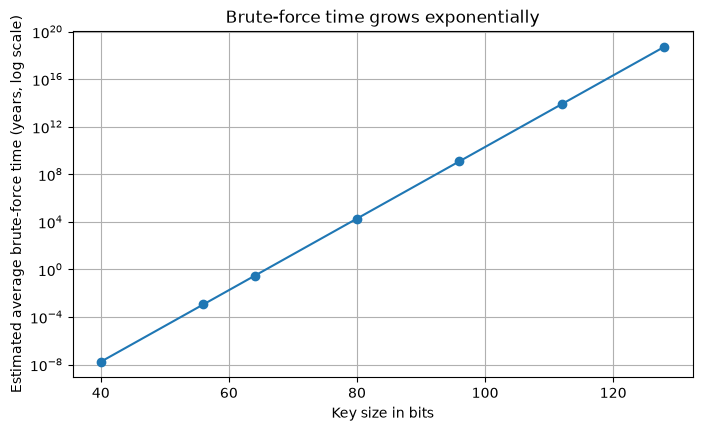

In [6]:
key_sizes = [40, 56, 64, 80, 96, 112, 128]
years = [brute_force_years(bits, keys_per_second=1e12) for bits in key_sizes]

plt.figure(figsize=(8, 4.5))
plt.semilogy(key_sizes, years, marker='o')
plt.xlabel('Key size in bits')
plt.ylabel('Estimated average brute-force time (years, log scale)')
plt.title('Brute-force time grows exponentially')
plt.grid(True, which='both')
plt.show()

## Part 4: Parallelism and Multiple Targets

Some attacks can be split across many machines. Brute-force key search is one of them.

If an attacker has `2^20` cores and is happy to break any one of `2^20` targets, the effective brute-force cost is reduced by `2^40`.

That is substantial, but it does **not** make 128-bit security weak.

In [7]:
base = brute_force_years(128, keys_per_second=1e9, cores=1, targets=1)
reduced = brute_force_years(128, keys_per_second=1e9, cores=2**20, targets=2**20)
print(f"Single core, one target:       {base:.3e} years")
print(f"2^20 cores, 2^20 targets:     {reduced:.3e} years")
print(f"Reduction factor:             {base / reduced:.3e}")

Single core, one target:       5.391e+21 years
2^20 cores, 2^20 targets:     4.903e+09 years
Reduction factor:             1.100e+12


### Discussion

1. Why does the number of targets matter in large-scale attacks?
 If you only care to break one target, then the likelihood that a random key would hit a random target is higher with more targets.
2. Why does this not mean that 128-bit security is automatically unsafe?
 You can significantly increase the chance of hitting the 128-bit by a large margin and still be dozens of years from cracking even one target.
3. What assumptions in this model are unrealistic or incomplete?
 That there are no shortcuts, or human error, and the amount of hardware the hacker has and targets.

## Part 5: Key Size vs Security Level

A key's length gives an upper bound on the security level, but it does not guarantee that level.

A 128-bit symmetric key can provide 128-bit security **only if** the best attack is brute force.

Security can be lower when:

- the cipher has a shortcut attack,
- randomness is weak,
- keys are reused incorrectly,
- implementation leaks timing or power information,
- the system stores the key insecurely,
- a compatibility mode allows weak parameters.

### Scenario Analysis

For each system below, estimate whether the claimed security level is believable.

| Scenario | Claimed Security | Your Evaluation |
|---|---:|---|
| AES-128 with keys generated using `secrets.token_bytes(16)` | 128-bit | 128-bit |
| AES-256 where the key is committed to GitHub | 256-bit | 0 bits |
| A custom cipher with a 256-bit key and no public cryptanalysis | 256-bit | Unsafe, untested |
| A password-derived key from the password `password123` | depends | Unsafe, common password |
| RSA with an outdated 512-bit modulus | high? | low, outdated |

Write your answers in Markdown below.

## Part 6: Generating Symmetric Keys Safely

For symmetric keys, key generation is conceptually simple: request enough random bytes from a cryptographic PRNG.

In Python, use `secrets` or a trusted cryptographic library. Do **not** use the `random` module for cryptographic keys.

In [8]:
def generate_symmetric_key(bits: int = 128) -> bytes:
    """Generate a symmetric key using Python's cryptographic randomness source."""
    if bits <= 0 or bits % 8 != 0:
        raise ValueError("bits must be a positive multiple of 8")
    return secrets.token_bytes(bits // 8)

key_128 = generate_symmetric_key(128)
key_256 = generate_symmetric_key(256)
print(f"128-bit key: {key_128.hex()}")
print(f"256-bit key: {key_256.hex()}")
print(len(key_128), 'bytes')
print(len(key_256), 'bytes')

128-bit key: fae15e2b88d08240ff0a9c02591922b5
256-bit key: e1c10dbcca3f2570aa74de2b68c0b065208cdf0f5226c15eefd1b680cde266b5
16 bytes
32 bytes


### Check Yourself

Why is `secrets.token_bytes(16)` appropriate for a 128-bit symmetric key, while `random.getrandbits(128)` is not appropriate for cryptographic key generation?
 Random is predictable and deterministic while secrets is random and secure.

## Part 7: Toolkit Integration

This week adds a small `security` module to your cryptographic toolkit. The module is not an implementation of a cipher. Instead, it contains helper functions for reasoning about security levels and brute-force cost.

Suggested path:

```text
crypto_toolkit/security/security_levels.py
```

Run the next cell from your toolkit repository root to create the file.

In [ ]:
module_path = Path('crypto_toolkit/security')
module_path.mkdir(parents=True, exist_ok=True)
(module_path / '__init__.py').write_text('from .security_levels import bit_security, brute_force_success_probability, brute_force_years, generate_symmetric_key\n')

module_code = '''
from __future__ import annotations

import math
import secrets

SECONDS_PER_YEAR = 60 * 60 * 24 * 365.25


def bit_security(operations: int | float) -> float:
    """Convert an attack cost in operations to a bit-security estimate."""
    if operations <= 0:
        raise ValueError('operations must be positive')
    return math.log2(operations)


def brute_force_success_probability(key_bits: int, attempts: int) -> float:
    """Return the probability of brute-force success after a number of attempts."""
    if key_bits <= 0:
        raise ValueError('key_bits must be positive')
    if attempts < 0:
        raise ValueError('attempts cannot be negative')
    return min(attempts / (2 ** key_bits), 1.0)


def brute_force_years(key_bits: int, keys_per_second: float, cores: int = 1, targets: int = 1, average_case: bool = True) -> float:
    """Estimate brute-force search time in years under a simplified model."""
    if key_bits <= 0:
        raise ValueError('key_bits must be positive')
    if keys_per_second <= 0:
        raise ValueError('keys_per_second must be positive')
    if cores <= 0 or targets <= 0:
        raise ValueError('cores and targets must be positive')
    attempts = 2 ** key_bits
    if average_case:
        attempts /= 2
    attempts /= cores
    attempts /= targets
    seconds = attempts / keys_per_second
    return seconds / SECONDS_PER_YEAR


def generate_symmetric_key(bits: int = 128) -> bytes:
    """Generate a symmetric key using Python's cryptographic randomness source."""
    if bits <= 0 or bits % 8 != 0:
        raise ValueError('bits must be a positive multiple of 8')
    return secrets.token_bytes(bits // 8)
'''

(module_path / 'security_levels.py').write_text(module_code)
print('Created crypto_toolkit/security/security_levels.py')

In [9]:
from crypto_toolkit.security import (
    bit_security,
    brute_force_success_probability,
    brute_force_years,
    generate_symmetric_key,
)

assert round(bit_security(2**20), 2) == 20.00
assert brute_force_success_probability(8, 256) == 1.0
assert len(generate_symmetric_key(128)) == 16
print('Basic toolkit checks passed.')

ModuleNotFoundError: No module named 'crypto_toolkit'

## Part 8: Security Engineering Questions

Answer these in Markdown.

1. A system advertises “AES-256 encryption.” What additional questions would you ask before trusting the claim?
 Where is the key stored, how is it generated, is it using an outdated version?
2. Why might a short-lived 64-bit key be acceptable in a tightly controlled system, while a 64-bit long-term key would be unacceptable?
 A one time use for something needed briefly wouldn't be cracked before it is discarded, but in the long-term 64-bits isn't outside of the possbility to be cracked. 
3. What is the difference between saying “no one has broken this yet” and saying “this has a security proof”? Which one applies to AES?
 One is saying that it has been tried and succeeded practically for a period of time, while the other says its theoretically secure and here's why. AES is found to fall under "no one has brokent this yet"
4. Explain why a private key stored in source code can destroy the security of an otherwise strong cryptographic system.
 People look through source code all the time, so if they find the key then it doesn't matter how hard it is to brute force a key, given it was right there. 
5. How does this chapter reinforce the course theme “security is a system property”?
 Security is dependent upon how a system is built, so if it isn't constructed properly with security as a property then it doesn't matter what your encryption is, since people could just get around it. 

## Final Reflection

Return to the big question:

> When we say a cryptographic system is secure, what claim are we actually making?

Write a 5–7 sentence answer. Your answer should mention attacker resources, probability of success, key generation, and implementation assumptions.

The claim states that it is out of the realm of reasonable probability that someone would break figure out the key and break into the system. This is done by have large enough keys that someone could not reasonably brute force it, in other words, making the probability of guessing correct as close to 0 as possible even given trillions of chances. The claim also states that the key itself is secure so its generation cannot be figured out. This includes using secure methods of key generation that are nondeterministic, but as close to random as possible, so reliant on something random.

## Submission Checklist

Before submitting:

- [ ] I answered the reading check questions.
- [ ] I ran all code cells.
- [ ] I completed the scenario analysis.
- [ ] I created or updated the `crypto_toolkit/security/security_levels.py` module.
- [ ] I answered the security engineering questions.
- [ ] I completed the final reflection.
- [ ] I committed and pushed my work to GitHub.